# 04 — Mayer bond-order analysis

Compare selected matched and functionalized-only bonds.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make figures independent of PyCharm/Jupyter dark-theme defaults.
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
    }
)

ROOT = Path("..").resolve()
RESULTS = ROOT / "results" / "ground_state"
FIGURES = ROOT / "figures"
SYSTEM_ORDER = ["pdi", "pdi_terminal_functionalized"]
SYSTEM_LABELS = {
    "pdi": "Parent PDI",
    "pdi_terminal_functionalized": "Terminal-functionalized PDI",
}

In [2]:
mayer = pd.read_csv(RESULTS / "bond_orders" / "mayer_bond_orders.csv")
selected_bonds = pd.read_csv(ROOT / "config" / "selected_bonds_candidates.csv")
MAYER_FIGURES = FIGURES / "bond_orders"
MAYER_FIGURES.mkdir(parents=True, exist_ok=True)
display(mayer.head())
display(selected_bonds.head())

,system,atom_i,element_i,atom_j,element_j,bond_type,mayer_bond_order,region_i,label_i,region_j,label_j,source_file
0,pdi,1,C,2,C,C-C,1.035793,core,C1,core,C2,calculations/pdi/multiwfn_analysis/bond_orders...
1,pdi,1,C,6,C,C-C,1.256176,core,C1,core,C6,calculations/pdi/multiwfn_analysis/bond_orders...
2,pdi,1,C,18,C,C-C,0.060123,core,C1,middle,C18,calculations/pdi/multiwfn_analysis/bond_orders...
3,pdi,1,C,20,C,C-C,1.444639,core,C1,middle,C20,calculations/pdi/multiwfn_analysis/bond_orders...
4,pdi,2,C,3,C,C-C,1.256432,core,C2,core,C3,calculations/pdi/multiwfn_analysis/bond_orders...


,bond_id,label,parent_i,parent_j,functionalized_i,functionalized_j,comparison_type
0,cc_1,C-C,1.0,2.0,1,2,matched
1,cc_2,C-C,1.0,6.0,1,6,matched
2,cc_3,C-C,1.0,20.0,1,20,matched
3,cc_4,C-C,2.0,3.0,2,3,matched
4,cc_5,C-C,2.0,7.0,2,7,matched


In [3]:
required = {"system","atom_i","atom_j","element_i","element_j","mayer_bond_order"}
missing = required - set(mayer.columns)
assert not missing, f"Missing columns: {sorted(missing)}"
assert set(mayer["system"]) == set(SYSTEM_ORDER)
mayer.groupby("system")["mayer_bond_order"].agg(["count","min","max","mean","median"])

,count,min,max,mean,median
system,,,,,
pdi,64,-0.177718,2.185099,0.906214,1.006010
pdi_terminal_functionalized,92,-0.148981,2.074705,0.945460,0.980129


In [4]:
def normalize_pairs(df, i_col, j_col):
    out = df.copy()
    i = pd.to_numeric(out[i_col], errors="coerce")
    j = pd.to_numeric(out[j_col], errors="coerce")
    out["atom_i_normalized"] = np.minimum(i, j)
    out["atom_j_normalized"] = np.maximum(i, j)
    return out

mayer_n = normalize_pairs(mayer, "atom_i", "atom_j")
rows=[]
for r in selected_bonds.to_dict("records"):
    for system, i_key, j_key in [
        ("pdi","parent_i","parent_j"),
        ("pdi_terminal_functionalized","functionalized_i","functionalized_j"),
    ]:
        if pd.isna(r.get(i_key)) or pd.isna(r.get(j_key)):
            continue
        rows.append({"bond_id":r.get("bond_id",r["label"]),"label":r["label"],"region":r.get("region",""),"comparison_type":r.get("comparison_type",""),"system":system,"atom_i":int(r[i_key]),"atom_j":int(r[j_key])})
selected_long = normalize_pairs(pd.DataFrame(rows), "atom_i", "atom_j")
selected_mayer = selected_long.merge(mayer_n[["system","atom_i_normalized","atom_j_normalized","element_i","element_j","mayer_bond_order"]], on=["system","atom_i_normalized","atom_j_normalized"], how="left", validate="many_to_one")
missing_rows = selected_mayer[selected_mayer["mayer_bond_order"].isna()]
if not missing_rows.empty:
    display(missing_rows)
    raise ValueError("Selected bonds missing from parsed Mayer table; check indices or threshold.")
selected_mayer

,bond_id,label,region,comparison_type,system,atom_i,atom_j,atom_i_normalized,atom_j_normalized,element_i,element_j,mayer_bond_order
0,cc_1,C-C,,matched,pdi,1,2,1,2,C,C,1.035793
1,cc_1,C-C,,matched,pdi_terminal_functionalized,1,2,1,2,C,C,1.044586
2,cc_2,C-C,,matched,pdi,1,6,1,6,C,C,1.256176
3,cc_2,C-C,,matched,pdi_terminal_functionalized,1,6,1,6,C,C,1.251607
4,cc_3,C-C,,matched,pdi,1,20,1,20,C,C,1.444639
...,...,...,...,...,...,...,...,...,...,...,...,...
77,newcc_4,new C-C,,functionalized_only,pdi_terminal_functionalized,32,38,32,38,C,C,0.970010
78,newcc_5,new C-C,,functionalized_only,pdi_terminal_functionalized,33,36,33,36,C,C,0.981994
79,newcc_6,new C-C,,functionalized_only,pdi_terminal_functionalized,34,35,34,35,C,C,0.982209
80,newcc_7,new C-C,,functionalized_only,pdi_terminal_functionalized,37,39,37,39,C,C,0.982376


In [5]:
comparison = selected_mayer.pivot_table(index=["bond_id","label","region","comparison_type"], columns="system", values="mayer_bond_order", aggfunc="first").reset_index()
for s in SYSTEM_ORDER:
    if s not in comparison.columns:
        comparison[s] = np.nan
comparison["delta_mayer_bond_order"] = comparison["pdi_terminal_functionalized"] - comparison["pdi"]
comparison = comparison.sort_values("delta_mayer_bond_order", key=lambda x: x.abs(), ascending=False)
comparison.to_csv(RESULTS / "bond_orders" / "selected_mayer_bond_comparison.csv", index=False)
comparison

system,bond_id,label,region,comparison_type,pdi,pdi_terminal_functionalized,delta_mayer_bond_order
31,co_2,C-O,,matched,2.185099,2.067917,-0.117183
33,co_4,C-O,,matched,2.184185,2.067206,-0.116979
32,co_3,C-O,,matched,2.184366,2.073776,-0.110590
30,co_1,C-O,,matched,2.184900,2.074705,-0.110195
28,cn_1,C-N,,matched,1.179847,1.156355,-0.023492
29,cn_2,C-N,,matched,1.179399,1.156443,-0.022955
10,cc_19,C-C,,matched,0.939799,0.921399,-0.018400
19,cc_27,C-C,,matched,0.936787,0.920472,-0.016316
7,cc_16,C-C,,matched,0.938753,0.925984,-0.012769
16,cc_24,C-C,,matched,0.936233,0.925482,-0.010751


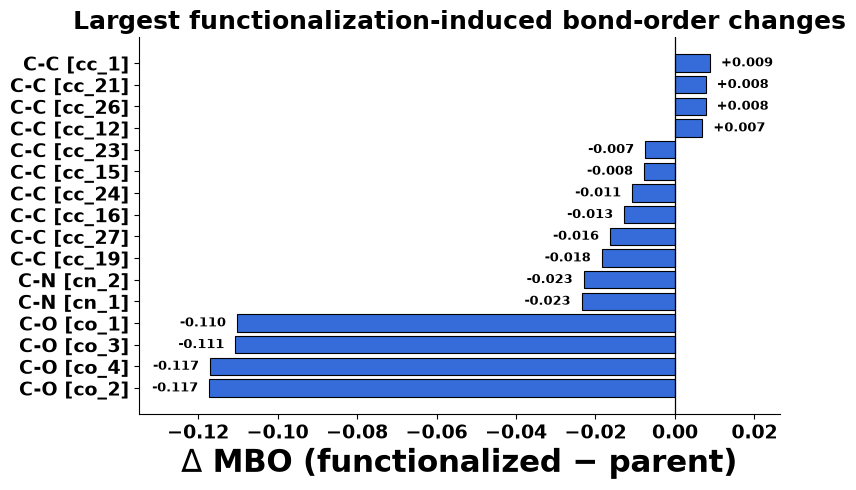

In [6]:
matched = comparison.dropna(
    subset=["pdi", "pdi_terminal_functionalized"]
).copy()

matched["bond_label"] = matched.apply(
    lambda row: (
        f'{row["label"]} '
        f'[{row["bond_id"]}]'
    ),
    axis=1,
)

top_changes = (
    matched.assign(
        absolute_delta=matched[
            "delta_mayer_bond_order"
        ].abs()
    )
    .sort_values("absolute_delta", ascending=False)
    .head(16)
    .sort_values("delta_mayer_bond_order")
)

fig, ax = plt.subplots(
    figsize=(8,5),
    facecolor="white",
)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

y = np.arange(len(top_changes))
values = top_changes["delta_mayer_bond_order"].to_numpy()

ax.barh(
    y,
    values,
    edgecolor="black",
    linewidth=0.8,
)
ax.axvline(0, color="black", linewidth=0.9)
ax.set_yticks(y)
ax.set_yticklabels(top_changes["bond_label"])

ax.tick_params(
    axis="x",
    labelsize=14,
    colors="black",
)
ax.tick_params(
    axis="y",
    labelsize=14,
    colors="black",
)
for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")
    tick.set_color("black")
for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")
    tick.set_color("black")

ax.set_xlabel(
    r"$\mathrm{\Delta}$ MBO (functionalized − parent)",
    fontsize=22,
    fontweight="bold",
    color="black",
)
ax.set_title(
    "Largest functionalization-induced bond-order changes",
    fontsize=18,
    fontweight="bold",
    color="black",
)

# Reserve explicit space beyond both bar ends so value labels always sit
# outside the bars and never collide with the left y-axis spine.
value_min = min(float(values.min()), 0.0)
value_max = max(float(values.max()), 0.0)
value_span = max(value_max - value_min, 0.02)
horizontal_padding = 0.14 * value_span

ax.set_xlim(
    value_min - horizontal_padding,
    value_max + horizontal_padding,
)

for y_pos, value in zip(y, values, strict=True):
    is_positive = value >= 0

    ax.annotate(
        f"{value:+.3f}",
        xy=(value, y_pos),
        xytext=(8 if is_positive else -8, 0),
        textcoords="offset points",
        va="center",
        ha="left" if is_positive else "right",
        fontsize=9,
        fontweight="bold",
        color="black",
        clip_on=False,
    )

ax.spines[["top", "right"]].set_visible(False)
for spine in ax.spines.values():
    spine.set_edgecolor("black")
ax.xaxis.label.set_color("black")
ax.yaxis.label.set_color("black")
fig.tight_layout()
fig.savefig(
    MAYER_FIGURES / "largest_selected_mayer_changes.pdf",
    bbox_inches="tight",
)
fig.savefig(
    MAYER_FIGURES / "largest_selected_mayer_changes.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()